# Experiment: Figure 2 Micro Dynamics Scheme (Calibrated Constant Drift)

This notebook rewrites the Figure 2 micro-dynamics schematic using the real calibrated model dynamics rather than the older linear-`c_BE` approximation. The workflow is:

1. build the stable baseline model in `target_diffusion` mode,
2. calibrate a shared `kappa` with `prepare_target_diffusion_mode()`,
3. run two deterministic constant-drift trials with `+v` and `-v`, and
4. render the layered edge-bump schematic from the actual simulated trajectories.


In [8]:
from __future__ import annotations

import runpy
from pathlib import Path

_NOTEBOOK_SETUP = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    helper = candidate / "figures_code" / "notebook_setup.py"
    if helper.exists():
        _NOTEBOOK_SETUP = runpy.run_path(str(helper))
        break
if _NOTEBOOK_SETUP is None:
    raise RuntimeError("Could not locate figures_code/notebook_setup.py")

REPO_ROOT = _NOTEBOOK_SETUP["REPO_ROOT"]

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from CANN_DDM_model_rate_based import CANN_DDM_model
from rate_model_core.default_params import build_stable_default_params

## Shared calibration and simulation helpers

Use the stable baseline, calibrate a shared `kappa`, then run two deterministic constant-drift cases starting from the same initial condition `x0 = 0.5`.


In [9]:
THETA_MARGIN = 0.02
C_BE_SWEEP = np.linspace(-0.2, 0.2, 11)
MIN_ACCUMULATION_SAMPLES = 200

DRIFT_MAG = 1.0
NOISE_SCALE = 0.0
X0 = 0.5
SEED = 4

FIGURE_DUR = 720
T_START = 80
DT_MODEL = 1.0
SNAPSHOT_START = T_START + 30
SNAPSHOT_STOP = 520
SNAPSHOT_STEP = 55
SNAPSHOT_TIMES = list(range(SNAPSHOT_START, SNAPSHOT_STOP, SNAPSHOT_STEP))

COLOR_BUMP = "#716db2"
COLOR_EDGE = "#1d52a1"
COLOR_DRIVE = "black"
COLOR_CURRENT = "red"


def build_baseline_params(*, drift_rate: float, noise_scale: float = NOISE_SCALE, seed: int = SEED, kappa: float | None = None):
    params = build_stable_default_params()
    params["bump_pop"]["noise_scale_bump"] = 0.0
    params["edge_pop"]["noise_scale_edge"] = 0.0
    params["edge_pop"]["c_EB"] = 0.1

    c_be_params = {
        "mode": "target_diffusion",
        "theta_margin": THETA_MARGIN,
    }
    if kappa is not None:
        c_be_params["kappa"] = float(kappa)
    params["bump_pop"]["c_BE_params"] = c_be_params

    params["decision_space_params"]["decision_mode"] = "continuous"
    params["decision_space_params"]["decision_paradigm"] = "free_response"
    params["decision_space_params"]["t_start"] = int(T_START)
    params["decision_space_params"]["dur"] = int(FIGURE_DUR)
    params["decision_space_params"]["max_time"] = int(FIGURE_DUR)
    params["decision_space_params"]["dt_DDM"] = float(DT_MODEL)
    params["decision_space_params"]["x0"] = float(X0)
    params["decision_space_params"]["seed"] = int(seed)
    params["decision_space_params"]["drift_rate"] = float(drift_rate)
    params["decision_space_params"]["noise_scale"] = float(noise_scale)
    return params


def prepare_shared_calibration(seed: int = SEED):
    model = CANN_DDM_model(CANN_params=build_baseline_params(drift_rate=0.0, noise_scale=0.0, seed=seed))
    calibration = model.prepare_target_diffusion_mode(
        c_be_sweep=C_BE_SWEEP,
        min_accumulation_samples=MIN_ACCUMULATION_SAMPLES,
    )
    return calibration


def run_constant_drive_case(*, drift_rate: float, kappa: float, seed: int = SEED):
    model = CANN_DDM_model(
        CANN_params=build_baseline_params(
            drift_rate=drift_rate,
            noise_scale=NOISE_SCALE,
            seed=seed,
            kappa=kappa,
        )
    )
    runner = model.run_simulation(
        mon_vars=["r_E", "r_B", "I_BE", "I_EB", "theta_E", "theta_B", "x_E", "x_B", "v_drive", "c_BE_dyn", "hit_boundary"],
        progress_bar=False,
        dt=DT_MODEL,
        get_RT=False,
    )
    return {
        "drift_rate": float(drift_rate),
        "times": np.arange(len(runner.mon.x_E), dtype=float),
        "r_E": np.asarray(runner.mon.r_E),
        "r_B": np.asarray(runner.mon.r_B),
        "I_BE": np.asarray(runner.mon.I_BE),
        "I_EB": np.asarray(runner.mon.I_EB),
        "theta_E": np.asarray(runner.mon.theta_E).reshape(-1),
        "theta_B": np.asarray(runner.mon.theta_B).reshape(-1),
        "x_E": np.asarray(runner.mon.x_E).reshape(-1),
        "x_B": np.asarray(runner.mon.x_B).reshape(-1),
        "v_drive": np.asarray(runner.mon.v_drive).reshape(-1),
        "c_BE_dyn": np.asarray(runner.mon.c_BE_dyn).reshape(-1),
        "hit_boundary": np.asarray(runner.mon.hit_boundary).reshape(-1),
        "model": model,
    }


def summarize_case(case: dict):
    hit = np.flatnonzero(case["hit_boundary"])
    first_hit = int(hit[0]) if hit.size else None
    return {
        "drift_rate": float(case["drift_rate"]),
        "theta_E_start": float(case["theta_E"][T_START]),
        "theta_E_end": float(case["theta_E"][-1]),
        "theta_B_end": float(case["theta_B"][-1]),
        "x_E_end": float(case["x_E"][-1]),
        "mean_abs_alignment_error": float(np.mean(np.abs(case["theta_B"] - case["theta_E"]))),
        "c_BE_dyn_min": float(np.min(case["c_BE_dyn"][T_START:])),
        "c_BE_dyn_max": float(np.max(case["c_BE_dyn"][T_START:])),
        "first_boundary_hit_ms": first_hit,
    }

## Calibrate shared `kappa`

The calibration is performed once and then reused for both the positive- and negative-drift cases.


In [10]:
calibration = prepare_shared_calibration()

calibration_summary = {
    "kappa": float(calibration["kappa"]),
    "certificate_passed": bool(calibration["certificate_passed"]),
    "c_be_theta_max": float(calibration["c_be_theta_max"]),
    "effective_c_be_max": float(calibration["effective_c_be_max"]),
    "valid_c_be_max": float(calibration["valid_c_be_max"]),
}
calibration_summary

{'kappa': 0.01565674187066247,
 'certificate_passed': True,
 'c_be_theta_max': 0.5228267625874745,
 'effective_c_be_max': 0.0,
 'valid_c_be_max': 0.2}

## Run the two constant-drift cases

Both cases use the same calibrated `kappa`, the same stable baseline, and the same initial condition `x0 = 0.5`.


In [11]:
case_pos = run_constant_drive_case(drift_rate=+DRIFT_MAG, kappa=float(calibration["kappa"]))
case_neg = run_constant_drive_case(drift_rate=-DRIFT_MAG, kappa=float(calibration["kappa"]))

case_pos_summary = summarize_case(case_pos)
case_neg_summary = summarize_case(case_neg)

case_pos_summary, case_neg_summary

({'drift_rate': 1.0,
  'theta_E_start': -0.9654607176780701,
  'theta_E_end': 1.2572486400604248,
  'theta_B_end': 1.163278341293335,
  'x_E_end': 0.9865767955780029,
  'mean_abs_alignment_error': 0.041209135204553604,
  'c_BE_dyn_min': 0.03274185210466385,
  'c_BE_dyn_max': 0.4163571298122406,
  'first_boundary_hit_ms': 553},
 {'drift_rate': -1.0,
  'theta_E_start': -0.970362663269043,
  'theta_E_end': -1.553694725036621,
  'theta_B_end': -1.5540363788604736,
  'x_E_end': 0.019243378192186356,
  'mean_abs_alignment_error': 0.005080722272396088,
  'c_BE_dyn_min': 0.01724459044635296,
  'c_BE_dyn_max': 0.03274185210466385,
  'first_boundary_hit_ms': 576})

## Layered schematic figure

Render the constant input row plus the actual simulated profile snapshots for `I_BE`, `r_E`, `I_EB`, and `r_B` for the `+v` and `-v` trials.


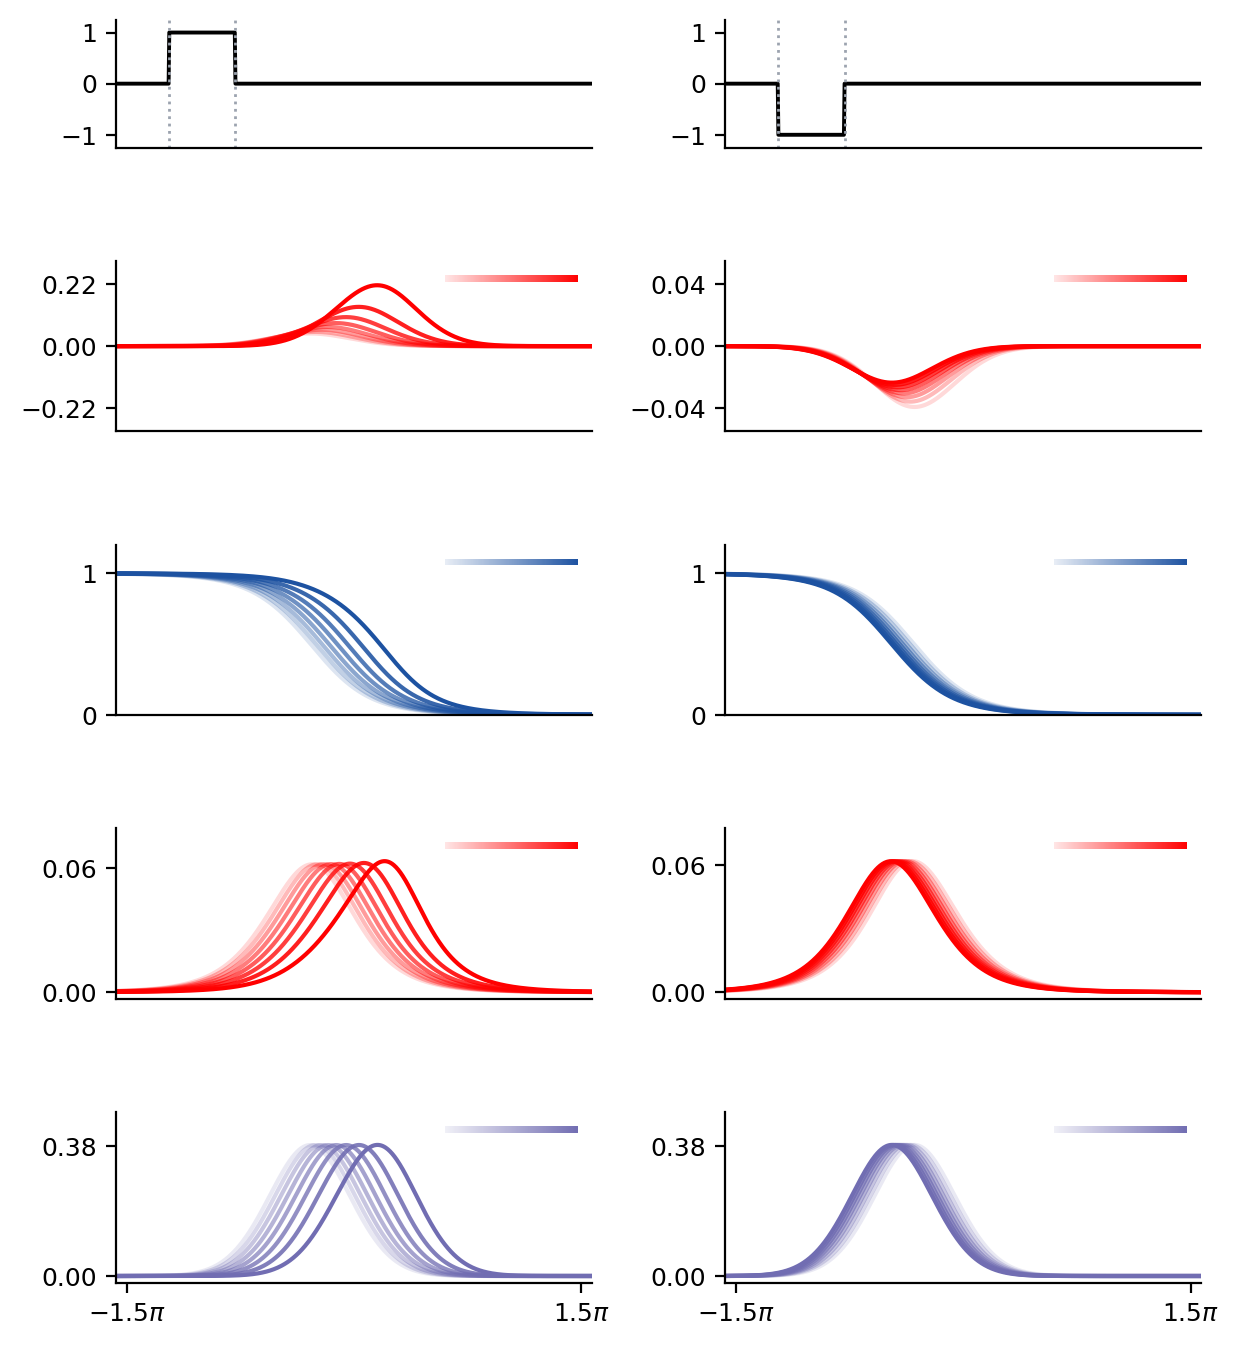

PosixPath('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/figure2/fig2_micro_dyn.png')

In [12]:
def add_alpha_colorbar(ax, base_color, label=None):
    rgb = np.array(to_rgb(base_color))
    alphas = np.linspace(0.1, 1.0, 256)
    colors = np.zeros((256, 4))
    colors[:, :3] = rgb
    colors[:, 3] = alphas
    cmap = ListedColormap(colors)
    norm = plt.Normalize(0.1, 1.0)

    cax = inset_axes(ax, width="28%", height="4%", loc="upper right", borderpad=0.5)
    cb = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cax, orientation="horizontal")
    cb.set_ticks([])
    cb.outline.set_visible(False)
    cax.set_xticks([])
    cax.set_yticks([])
    for spine in cax.spines.values():
        spine.set_visible(False)
    if label is not None:
        cax.text(1.02, 0.5, label, transform=cax.transAxes, va="center", ha="left", fontsize=8)


def plot_snapshot_row(ax, traces, time_points, neural_range, neural_space, color, symmetric=False):
    for idx, t in enumerate(time_points):
        alpha = 0.15 + 0.85 * idx / max(len(time_points) - 1, 1)
        ax.plot(neural_space, traces[t, neural_range], color=color, alpha=alpha, linewidth=1.5)
    ax.set_xlim(float(neural_space[0]), float(neural_space[-1]))
    if symmetric:
        peak = float(np.max(np.abs(traces[time_points][:, neural_range])))
        ax.set_ylim(-1.4 * peak, 1.4 * peak)
        ax.set_yticks([-round(peak, 2), 0.0, round(peak, 2)])
    else:
        peak = float(np.max(traces[time_points][:, neural_range]))
        ax.set_ylim(-0.05 * max(peak, 1e-6), 1.25 * peak)
        ax.set_yticks([0.0, round(peak, 2)])


fig, ax = plt.subplots(5, 2, figsize=(7.0, 8.2), gridspec_kw={"height_ratios": [0.75, 1, 1, 1, 1]})
fontsize = 16
cases = [case_pos, case_neg]
neural_pad = 220
model = case_pos["model"]
neural_range = np.arange(max(0, model.geometry.k1 - neural_pad), min(model.num_E, model.geometry.k2 + neural_pad))
neural_space = np.asarray(model.idx_to_pos(neural_range), dtype=float)
#bottom_xticks = np.linspace(float(neural_space[0]), float(neural_space[-1]), 2)
bottom_xticks = [-1.5 * np.pi, 1.5 * np.pi]
bottom_xticklabels = [r"$-1.5\pi$", r"$1.5\pi$"]

for col, case in enumerate(cases):
    t_vals = case["times"]
    y = np.zeros_like(t_vals)
    y[T_START:T_START+100] = case["drift_rate"]
    ax[0, col].plot(t_vals, y, color=COLOR_DRIVE, linewidth=1.4)
    ax[0, col].axvline(T_START, color="#9ca3af", linestyle=":", linewidth=1.0)
    ax[0, col].axvline(T_START+100, color="#9ca3af", linestyle=":", linewidth=1.0)
    ax[0, col].set_xlim(0, FIGURE_DUR-1)
    ax[0, col].set_ylim(-1.25 * DRIFT_MAG, 1.25 * DRIFT_MAG)
    ax[0, col].set_yticks([-DRIFT_MAG, 0.0, DRIFT_MAG])
    ax[0, col].tick_params(labelbottom=False, bottom=False)

    plot_snapshot_row(ax[1, col], case["I_BE"], SNAPSHOT_TIMES, neural_range, neural_space, COLOR_CURRENT, symmetric=True)
    add_alpha_colorbar(ax[1, col], base_color=COLOR_CURRENT)
    ax[1, col].tick_params(labelbottom=False, bottom=False)

    plot_snapshot_row(ax[2, col], case["r_E"], SNAPSHOT_TIMES, neural_range, neural_space, COLOR_EDGE, symmetric=False)
    if col == 1:
        ax[2, col].set_yticks([0.0, 1.0])
    ax[2, col].set_ylim(0.0, 1.2)
    add_alpha_colorbar(ax[2, col], base_color=COLOR_EDGE)
    ax[2, col].tick_params(labelbottom=False, bottom=False)

    plot_snapshot_row(ax[3, col], case["I_EB"], SNAPSHOT_TIMES, neural_range, neural_space, COLOR_CURRENT, symmetric=False)
    add_alpha_colorbar(ax[3, col], base_color=COLOR_CURRENT)
    ax[3, col].tick_params(labelbottom=False, bottom=False)

    plot_snapshot_row(ax[4, col], case["r_B"], SNAPSHOT_TIMES, neural_range, neural_space, COLOR_BUMP, symmetric=False)
    add_alpha_colorbar(ax[4, col], base_color=COLOR_BUMP)
    ax[4, col].set_xticks(bottom_xticks)
    ax[4, col].set_xticklabels(bottom_xticklabels, fontsize=fontsize)
    ax[4, col].tick_params(labelbottom=True, bottom=True)

for axis in ax.flat:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.tick_params(labelsize=9)

fig.subplots_adjust(hspace=0.7, wspace=0.28)

output_path = REPO_ROOT / "figures" / "figure2" / "fig2_micro_dyn.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

output_path

## Notes

This version is intentionally driven by the calibrated `target_diffusion` mechanism. The left and right columns are separate real simulations with shared `kappa`, not mirrored copies of a single trajectory.
